<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/datatabularpart2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import the drive library from google.colab
from google.colab import drive

# Start the mounting process
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# ============================================
# Problem 7: Applying Row-Level Operations
# ============================================

# Step 1: Import libraries
import pandas as pd
from google.colab import drive


# Step 2: Mount Google Drive
drive.mount('/content/drive')


# Step 3: Read the stroke dataset
file_path = '/content/drive/MyDrive/AIHC5020/stroke/healthcare-dataset-stroke-data.csv'

stroke_df = pd.read_csv(file_path)


# Step 4: Check that the dataset loaded correctly
print("First 5 rows of the dataset:")
print(stroke_df.head())


# Step 5: Define a function to identify cardiovascular disease
def cardiovascular(row):
    if row['hypertension'] == 1 or row['heart_disease'] == 1:
        return 1
    else:
        return 0


# Step 6: Apply the function to every row
# axis=1 means apply the function row by row
stroke_df['cardiovascular_disease'] = stroke_df.apply(
    cardiovascular,
    axis=1
)


# Step 7: Display the requested columns
print("\nFirst 5 rows of the cardiovascular disease columns:")

print(
    stroke_df[
        ['hypertension',
         'heart_disease',
         'cardiovascular_disease']
    ].head()
)


# Step 8: Display value counts
print("\nCardiovascular disease value counts:")

print(stroke_df['cardiovascular_disease'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows of the dataset:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.

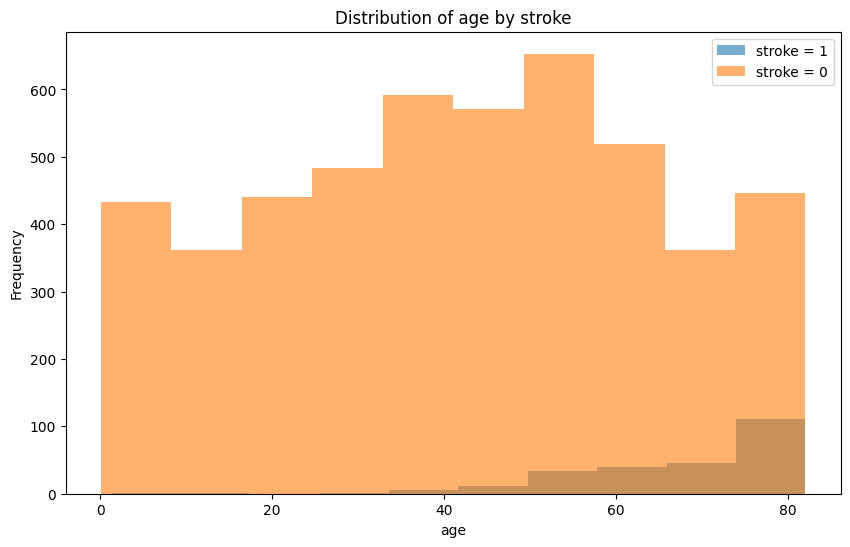

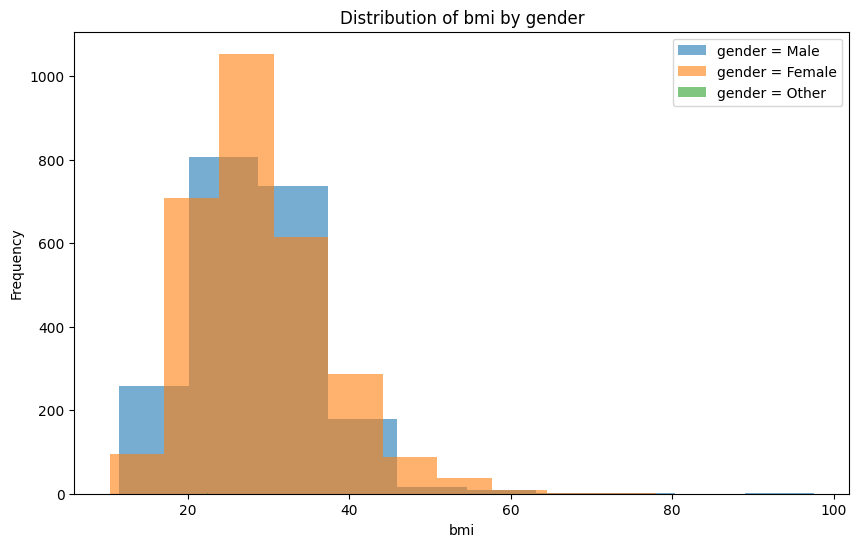

'stroke' appears to be categorical, not continuous.


In [11]:
# Problem 8: Exploratory visualizations

import matplotlib.pyplot as plt


def plot_histograms_by_category(df, continuous_col, categorical_col):

    # Check if both columns exist
    if continuous_col not in df.columns:
        print(f"Column '{continuous_col}' not found in dataframe.")
        return None

    if categorical_col not in df.columns:
        print(f"Column '{categorical_col}' not found in dataframe.")
        return None

    # Count unique values
    continuous_unique = df[continuous_col].nunique()
    categorical_unique = df[categorical_col].nunique()

    # Check whether continuous_col looks categorical
    if continuous_unique < 10:
        print(
            f"'{continuous_col}' appears to be categorical, "
            "not continuous."
        )
        return None

    # Check whether categorical_col looks continuous
    if categorical_unique >= 10:
        print(
            f"'{categorical_col}' appears to be continuous, "
            "not categorical."
        )
        return None

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Find unique categories
    categories = df[categorical_col].dropna().unique()

    # Loop through each category
    for category in categories:

        # Filter dataframe for current category
        subset = df[df[categorical_col] == category]

        # Plot histogram
        ax.hist(
            subset[continuous_col].dropna(),
            alpha=0.6,
            label=f'{categorical_col} = {category}'
        )

    # Add title and labels
    ax.set_title(
        f'Distribution of {continuous_col} by {categorical_col}'
    )

    ax.set_xlabel(continuous_col)
    ax.set_ylabel('Frequency')

    # Add legend
    ax.legend()

    # Show plot
    plt.show()


# -----------------------------------------
# Test 1: Age distribution by stroke
# -----------------------------------------
plot_histograms_by_category(
    stroke_df,
    'age',
    'stroke'
)


# -----------------------------------------
# Test 2: BMI distribution by gender
# -----------------------------------------
plot_histograms_by_category(
    stroke_df,
    'bmi',
    'gender'
)


# -----------------------------------------
# Test 3: Incorrect column types
# stroke is categorical and age is continuous
# -----------------------------------------
plot_histograms_by_category(
    stroke_df,
    'stroke',
    'age'
)

In [12]:
# Problem 9: Analyzing Group-wise Statistics with groupby

import pandas as pd


def calculate_stroke_prevalence(df, group_by_cols):

    # Check that all requested columns exist
    for col in group_by_cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in dataframe.")
            return None

    # Check that grouping columns are categorical
    # Fewer than 10 unique values = categorical
    for col in group_by_cols:
        if df[col].nunique() >= 10:
            print(f"Column '{col}' does not appear to be categorical.")
            return None

    # Group the dataframe
    grouped = df.groupby(group_by_cols)

    # Calculate total number of people in each group
    group_sizes = grouped.size()

    # Calculate number of stroke cases in each group
    stroke_counts = grouped['stroke'].sum()

    # Calculate stroke prevalence
    prevalence = stroke_counts / group_sizes

    # Convert the Series into a DataFrame
    result = prevalence.to_frame(name='stroke_prevalence')

    # Reset the index
    result = result.reset_index()

    # Return the final DataFrame
    return result


# -----------------------------------------
# Test 1: Group by smoking_status
# -----------------------------------------
result1 = calculate_stroke_prevalence(
    stroke_df,
    ['smoking_status']
)

print("Stroke prevalence by smoking status:")
print(result1)


# -----------------------------------------
# Test 2: Group by ever_married and work_type
# -----------------------------------------
result2 = calculate_stroke_prevalence(
    stroke_df,
    ['ever_married', 'work_type']
)

print("\nStroke prevalence by marriage and work type:")
print(result2)


# -----------------------------------------
# Test 3: Group by age
# This should produce an error message because
# age is a continuous variable
# -----------------------------------------
result3 = calculate_stroke_prevalence(
    stroke_df,
    ['age']
)

print(result3)


# -----------------------------------------
# Test 4: Incorrect capitalization
# The actual column is Residence_type
# -----------------------------------------
result4 = calculate_stroke_prevalence(
    stroke_df,
    ['residence_type']
)

print(result4)

Stroke prevalence by smoking status:
    smoking_status  stroke_prevalence
0          Unknown           0.030440
1  formerly smoked           0.079096
2     never smoked           0.047569
3           smokes           0.053232

Stroke prevalence by marriage and work type:
  ever_married      work_type  stroke_prevalence
0           No       Govt_job           0.051282
1           No   Never_worked           0.000000
2           No        Private           0.017052
3           No  Self-employed           0.063636
4           No       children           0.002911
5          Yes       Govt_job           0.050000
6          Yes        Private           0.064163
7          Yes  Self-employed           0.081805
Column 'age' does not appear to be categorical.
None
Column 'residence_type' not found in dataframe.
None


In [13]:
# Problem 10: Building a Preprocessing Pipeline for Analysis

import pandas as pd


def preprocess_for_analysis(df, cols_to_impute, cols_to_scale,
                            cols_to_encode, cols_to_drop):

    # Step 1: Make a copy so the original dataframe is not changed
    processed_df = df.copy()

    # Step 2a: Drop specified columns
    # errors='ignore' prevents an error if a column does not exist
    processed_df = processed_df.drop(
        columns=cols_to_drop,
        errors='ignore'
    )

    # Step 2b: Impute missing values using the column mean
    for col in cols_to_impute:
        processed_df[col] = processed_df[col].fillna(
            processed_df[col].mean()
        )

    # Step 2c: Standard scale numerical columns
    for col in cols_to_scale:

        mean = processed_df[col].mean()
        std = processed_df[col].std()

        # Create the new scaled column
        processed_df[f'{col}_scaled'] = (
            processed_df[col] - mean
        ) / std

        # Drop the original unscaled column
        processed_df = processed_df.drop(columns=[col])

    # Step 2d: One-hot encode categorical columns
    for col in cols_to_encode:

        encoded = pd.get_dummies(
            processed_df[col],
            prefix=col,
            drop_first=True,
            dtype=int
        )

        # Remove the original categorical column
        processed_df = processed_df.drop(columns=[col])

        # Add the new encoded columns
        processed_df = processed_df.join(encoded)

    # Return the processed dataframe
    return processed_df


# ------------------------------------------------
# Define the lists requested in the assignment
# ------------------------------------------------

impute_list = ['bmi']

scale_list = [
    'age',
    'avg_glucose_level',
    'bmi'
]

encode_list = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

drop_list = [
    'id',
    'location_code'
]


# ------------------------------------------------
# Run the preprocessing function
# ------------------------------------------------

processed_stroke_df = preprocess_for_analysis(
    stroke_df,
    impute_list,
    scale_list,
    encode_list,
    drop_list
)


# ------------------------------------------------
# Verify the results
# ------------------------------------------------

print("First 5 rows of processed data:")
print(processed_stroke_df.head())


print("\nDataFrame information:")
processed_stroke_df.info()

First 5 rows of processed data:
   hypertension  heart_disease  stroke  cardiovascular_disease  age_scaled  \
0             0              1       1                       1    1.051331   
1             0              0       1                       0    0.785993   
2             0              1       1                       1    1.626231   
3             0              0       1                       0    0.255317   
4             1              0       1                       1    1.582008   

   avg_glucose_level_scaled    bmi_scaled  gender_Male  gender_Other  \
0                  2.706111  1.001136e+00            1             0   
1                  2.121351  4.615102e-16            0             0   
2                 -0.005028  4.685314e-01            1             0   
3                  1.437217  7.153482e-01            0             0   
4                  1.501038 -6.356489e-01            0             0   

   ever_married_Yes  work_type_Never_worked  work_type_Private  \


In [14]:
# Problem 11: Joins in Pandas with merge()

import pandas as pd


# -----------------------------------------
# Step 1: Load the stroke dataset
# -----------------------------------------

stroke_path = '/content/drive/MyDrive/AIHC5020/stroke/healthcare-dataset-stroke-data.csv'

stroke_df = pd.read_csv(stroke_path)


# -----------------------------------------
# Step 2: Load the location codes dataset
# -----------------------------------------

location_path = '/content/drive/MyDrive/AIHC5020/stroke/location_codes.csv'

location_codes_df = pd.read_csv(location_path)


# -----------------------------------------
# Step 3: Perform a LEFT JOIN
# -----------------------------------------

merged_df = stroke_df.merge(
    location_codes_df,
    how='left',
    on='location_code'
)


# -----------------------------------------
# Step 4: Show the result
# -----------------------------------------

print(merged_df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  location_code          city state  
0       1            143         Miami    FL  
1       1            116  Indianap

In [15]:
# Problem 12: Introduction to SQL with DuckDB

# Import DuckDB
import duckdb


# Step 1: Write the SQL query
sql_query = """
SELECT *
FROM stroke_df AS s
LEFT JOIN location_codes_df AS l
ON s.location_code = l.location_code
WHERE l.state = 'NY'
"""


# Step 2 and 3: Execute the query
# and convert the result to a pandas DataFrame
sql_result_df = duckdb.query(sql_query).to_df()


# Step 4: Show the first 5 rows
print("First 5 rows:")
print(sql_result_df.head())


# Check the unique state values
print("\nUnique state values:")
print(sql_result_df['state'].unique())

First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0  37937  Female  75.0             0              1           No   
1  17004  Female  70.0             0              0          Yes   
2  56841    Male  58.0             0              1          Yes   
3  20426  Female  78.0             1              0           No   
4  66767  Female  67.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi smoking_status  \
0  Self-employed          Urban             109.78   NaN        Unknown   
1        Private          Urban             221.58  47.5   never smoked   
2        Private          Rural             240.59  31.4         smokes   
3        Private          Urban             203.87  45.7   never smoked   
4       Govt_job          Rural              94.61  28.4         smokes   

   stroke  location_code  location_code_1      city state  
0       1            181              181   Buffalo    NY  
1     